# 1. Exploración y comprensión de los datos

## 1.1. Descarga del _dataset_ "AirBnb Buenos Aires"

In [18]:
import urllib.request
urllib.request.urlretrieve("https://data.insideairbnb.com/argentina/ciudad-aut%C3%B3noma-de-buenos-aires/buenos-aires/2026-01-25/visualisations/listings.csv", "listings.csv")

('listings.csv', <http.client.HTTPMessage at 0x112b290f0>)

In [19]:
import pandas
df = pandas.read_csv('./listings.csv')

## 1.2. Verificación preliminar

In [20]:
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,42610838,"Puerto Madero a 3 cuadras, centro, bello , tea...",224049389,1469188629918707060,Gabriela,NaN,San Nicolas,-34.599976,-58.374195,Entire home/apt,NaN,7.0,0,NaN,NaN,2,244,0,NaN
1,1305876403852901802,Apart estudio en Microcentro,25649070,1465347917068117288,Federico,NaN,San Nicolas,-34.600382,-58.372692,Entire home/apt,NaN,2.0,1,2025-01-18,0.08,1,307,0,NaN
2,1542233033640525302,"Departamento en Buenos Aires, abasto shopping",153014015,1468500000533080859,Marco,NaN,Balvanera,-34.603295,-58.409527,Entire home/apt,NaN,7.0,0,NaN,NaN,1,326,0,NaN
3,1004530078359434134,Departamento en Recoleta,1409800,1462517876404348407,Marian,NaN,Balvanera,-34.599230,-58.407060,Entire home/apt,NaN,1.0,22,2025-12-07,0.80,39,365,3,NaN
4,800145927121871422,Coqueto para 4 personas,467965425,1470109782901816721,Maria Del Carmen,NaN,Almagro,-34.599767,-58.426499,Entire home/apt,NaN,1.0,0,NaN,NaN,2,365,0,NaN


In [21]:
df.tail()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
27343,1587119060096878911,Estudio luminoso en el corazón de Villa Crespo.,1534662,1462518725032785871,Florencia,NaN,Villa Crespo,-34.597425,-58.442220,Entire home/apt,NaN,1.0,1,2026-01-10,1.00,6,54,1,NaN
27344,37623532,Modern Top located Duplex Apartment! Up to 4 pax,2809500,1462609256411099848,Florencia,NaN,Palermo,-34.575020,-58.421840,Entire home/apt,NaN,30.0,12,2025-03-17,0.16,3,344,1,NaN
27345,1074846345919500333,Departamento Villa crespo I,133597828,1462947748907784667,Estudio H Apartments,NaN,Villa Crespo,-34.594473,-58.441314,Entire home/apt,NaN,2.0,4,2025-12-10,0.36,6,84,4,NaN
27346,1028342669639305203,"Depto a 8 min de Palermo,subte línea B 100 Mts.",49955010,1465763312015870684,Mariano,NaN,Villa Crespo,-34.600277,-58.437097,Entire home/apt,NaN,3.0,4,2025-12-05,0.15,1,269,3,NaN
27347,18517386,Apartment Full Equipment in Belgrano R,57658152,1466691284640462108,Ines,NaN,Belgrano,-34.568100,-58.456000,Entire home/apt,NaN,1.0,59,2025-12-31,0.56,1,44,2,NaN


## 1.3. Exploración de datos

Se visualiza tamaño del conjunto de datos, el número de elementos totales y el tipo de datos.
Se distinguen también las variables numéricas y categóricas.

In [22]:
print(f"Tamaño del conjunto de datos: {df.shape}\n")
print(f"Total de elementos: {df.size}\n")
print(f"Tipos de datos: \n{df.dtypes}\n")

Tamaño del conjunto de datos: (27348, 19)

Total de elementos: 519612

Tipos de datos: 
id                                  int64
name                                  str
host_id                             int64
host_profile_id                     int64
host_name                             str
neighbourhood_group               float64
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                               str
dtype: object



In [23]:
# Se distinguen variables númericas discretas y continuas
print(f"Variables numéricas discretas: {df.select_dtypes(include=['int']).columns.tolist()}\n")
print(f"Variables numéricas continuas: {df.select_dtypes(include=['float']).columns.tolist()}\n")
print(f"Número de variables numéricas: {len(df.select_dtypes(include=['number']).columns)}, de las cuales {len(df.select_dtypes(include=['int']).columns)} son discretas y {len(df.select_dtypes(include=['float']).columns)} son continuas\n")
# Se verifican las variables categóricas
print(f"Variables categóricas: {df.select_dtypes(include=['str']).columns.tolist()}\n")
# Número de variables categóricas
print(f"Número de variables categóricas: {len(df.select_dtypes(include=['str']).columns)}, de las cuales {len(df.select_dtypes(include=['category']).columns)} son ordinales y {len(df.select_dtypes(include=['str']).columns) - len(df.select_dtypes(include=['category']).columns)} son nominales\n")

Variables numéricas discretas: ['id', 'host_id', 'host_profile_id', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']

Variables numéricas continuas: ['neighbourhood_group', 'latitude', 'longitude', 'price', 'minimum_nights', 'reviews_per_month']

Número de variables numéricas: 13, de las cuales 7 son discretas y 6 son continuas

Variables categóricas: ['name', 'host_name', 'neighbourhood', 'room_type', 'last_review', 'license']

Número de variables categóricas: 6, de las cuales 0 son ordinales y 6 son nominales



Curiosidades y desafíos a priori:

- Datos duplicados
- Valores nulos
- Estadística descriptiva de las variables relevantes
- Tipos de alojamiento
- Rango temporal de reseñas
- Listados sin disponibilidad

In [24]:
print(f"Datos duplicados: {df.duplicated().sum()}")

Datos duplicados: 0


Los valores faltantes en *neighbourhood_group*, *price* y *license* no parecen ser al azar y corresponderían al tipo MNAR. Una suposición puede ser que estos datos son a partir de una encuesta y no se respondió acerca del precio o la licencia.

Los valores faltantes en *minimun_nights*, *last_review* y *review_per_month* parecen ser al azar, y corresponderían al tipo MAR.

In [25]:
print(f"Valores faltantes: \n{df.isnull().sum()}")

Valores faltantes: 
id                                    0
name                                  0
host_id                               0
host_profile_id                       0
host_name                             0
neighbourhood_group               27348
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                             27348
minimum_nights                      106
number_of_reviews                     0
last_review                        3303
reviews_per_month                  3303
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           26887
dtype: int64


In [26]:
cols_relevantes = ["latitude", "longitude", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365", "number_of_reviews_ltm"]
print("Estadísticas descriptivas:")
df[cols_relevantes].describe()

Estadísticas descriptivas:


,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,27348.000000,27348.000000,27242.000000,27348.000000,24045.000000,27348.000000,27348.000000,27348.000000
mean,-34.592076,-58.416340,4.748770,38.127176,1.464834,12.394398,239.999963,12.231827
std,0.017927,0.029938,16.434273,56.082583,1.559983,27.895493,113.614547,17.429681
min,-34.690056,-58.530890,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,-34.603202,-58.435973,1.000000,4.000000,0.390000,1.000000,151.000000,1.000000
50%,-34.591370,-58.418325,2.000000,17.000000,1.000000,2.000000,269.000000,5.000000
75%,-34.581471,-58.391140,3.000000,51.000000,2.030000,9.000000,344.000000,17.000000
max,-34.535630,-58.355403,730.000000,1044.000000,28.690000,188.000000,365.000000,329.000000


In [27]:
print("Tipos de alojamiento")
vc = df["room_type"].value_counts()
pct = df["room_type"].value_counts(normalize=True) * 100
pandas.DataFrame({"Cantidad": vc, "Porcentaje": pct.round(1).astype(str) + "%"})

Tipos de alojamiento


,Cantidad,Porcentaje
room_type,,
Entire home/apt,24890,91.0%
Private room,2249,8.2%
Shared room,132,0.5%
Hotel room,77,0.3%


In [28]:
print("Rango temporal de reseñas")
reviews = pandas.to_datetime(df["last_review"], errors="coerce")
print("- Primera reseña:\t", reviews.min())
print("- Última reseña:\t", reviews.max())
print("- Rango (días):\t\t", (reviews.max() - reviews.min()).days)

Rango temporal de reseñas
- Primera reseña:	 2013-01-06 00:00:00
- Última reseña:	 2026-01-25 00:00:00
- Rango (días):		 4767


In [29]:
sin_disponibilidad = (df["availability_365"] == 0).sum()
print("Listados sin disponibilidad")
print(f"- Registros sin disponibilidad: {sin_disponibilidad} ({sin_disponibilidad / len(df) * 100:.1f}%)")

Listados sin disponibilidad
- Registros sin disponibilidad: 283 (1.0%)


In [30]:
print("Precio nulo en todos los registros")
null_pct = df["price"].isnull().sum() / len(df) * 100
print(f"- Registros sin precio: {df['price'].isnull().sum()} ({null_pct:.1f}%)")

Precio nulo en todos los registros
- Registros sin precio: 27348 (100.0%)


In [31]:
print("Analisis de outliers en latitud y longitud")
print(f"- Latitud: {df['latitude'].min()} a {df['latitude'].max()}")
print(f"- Longitud: {df['longitude'].min()} a {df['longitude'].max()}")

Analisis de outliers en latitud y longitud
- Latitud: -34.6900558 a -34.53563
- Longitud: -58.53089 a -58.35540270049948


Análisis de outliers

In [32]:
# Se aplica el método del rango intercuartílico (IQR) para detectar outliers en las columnas relevantes
for col in cols_relevantes:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers en '{col}': {len(outliers)} ({len(outliers) / len(df) * 100:.1f}%)")

Outliers en 'latitude': 517 (1.9%)
Outliers en 'longitude': 151 (0.6%)
Outliers en 'minimum_nights': 3012 (11.0%)
Outliers en 'number_of_reviews': 1973 (7.2%)
Outliers en 'reviews_per_month': 1075 (3.9%)
Outliers en 'calculated_host_listings_count': 4074 (14.9%)
Outliers en 'availability_365': 0 (0.0%)
Outliers en 'number_of_reviews_ltm': 1770 (6.5%)


# 2. Aplicación de técnicas de visualización

A continuación se presentan algunos gráficos y técnicas de visualización para ilustrar las principales características del conjunto de datos.

Las variables seleccionadas para la visualización fueron: (TBD) *room_type*, *minimum_nights*, *number_of_reviews*, *reviews_per_month*.

La variable *room_type*, al ser categórica, se visualiza mediante un gráfico de barras. Se observa que casi la inmensa mayoría de los alojamientos (más del 90%) corresponden a apartamentos completos.

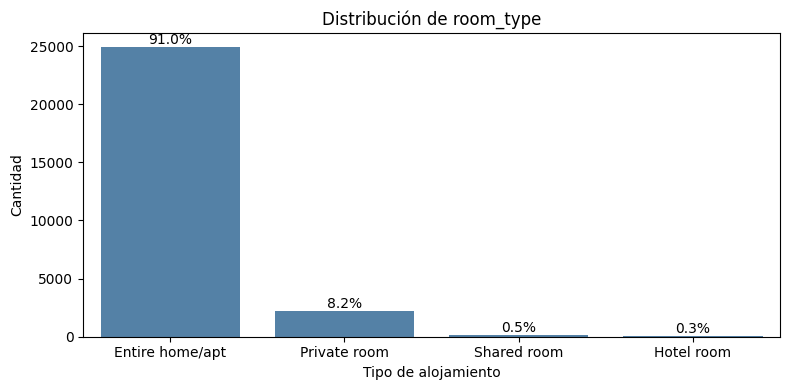

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='room_type', order=df['room_type'].value_counts().index, color='steelblue')

# Mostramos el porcentaje sobre cada barra ya que "Shared room" y "Hotel room" tienen muy pocos
total = len(df)
ax = plt.gca()
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Distribución de room_type')
plt.xlabel('Tipo de alojamiento')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()


La variable *neighbourhood* tiene altísima cardinalidad, por lo que para visualizarla mediante barras se realizó lo siguiente:
- Se redujeron las categorías a graficar a las 15 más frecuentes.
- Se agruparon las categorías restantes en una categoría "Otros".
- Se graficó horizontalmente para mejorar la legibilidad (los barrios generalmente tienen nombres largos dificiles de leer en el eje de abscisas).

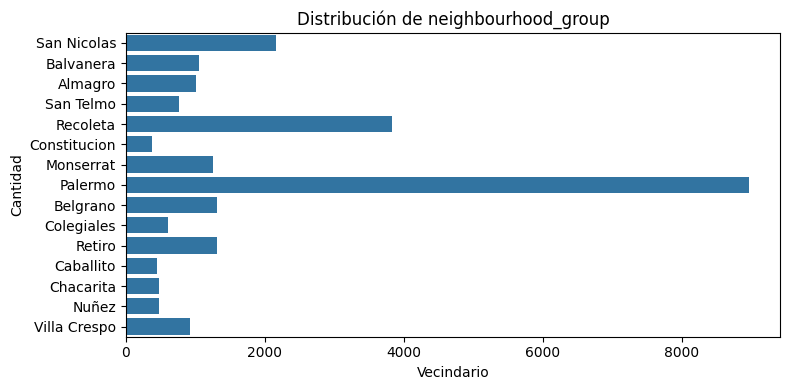

In [34]:
plt.figure(figsize=(8, 4))

top_n = df['neighbourhood'].value_counts().head(15).index
sns.countplot(data=df[df['neighbourhood'].isin(top_n)], y='neighbourhood')

plt.title('Distribución de neighbourhood_group')
plt.xlabel('Vecindario')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

Las variables *latitude* y *longitude* se pueden visualizar conjuntamente mediante un gráfico de dispersión, para tratar de observar la distribución geográfica de los alojamientos.

Se observa la gran dominancia de los alojamientos del tipo apartamento completo. Resulta muy interesante que el gráfico de dispersión da la silueta de la Ciudad de Buenos Aires.

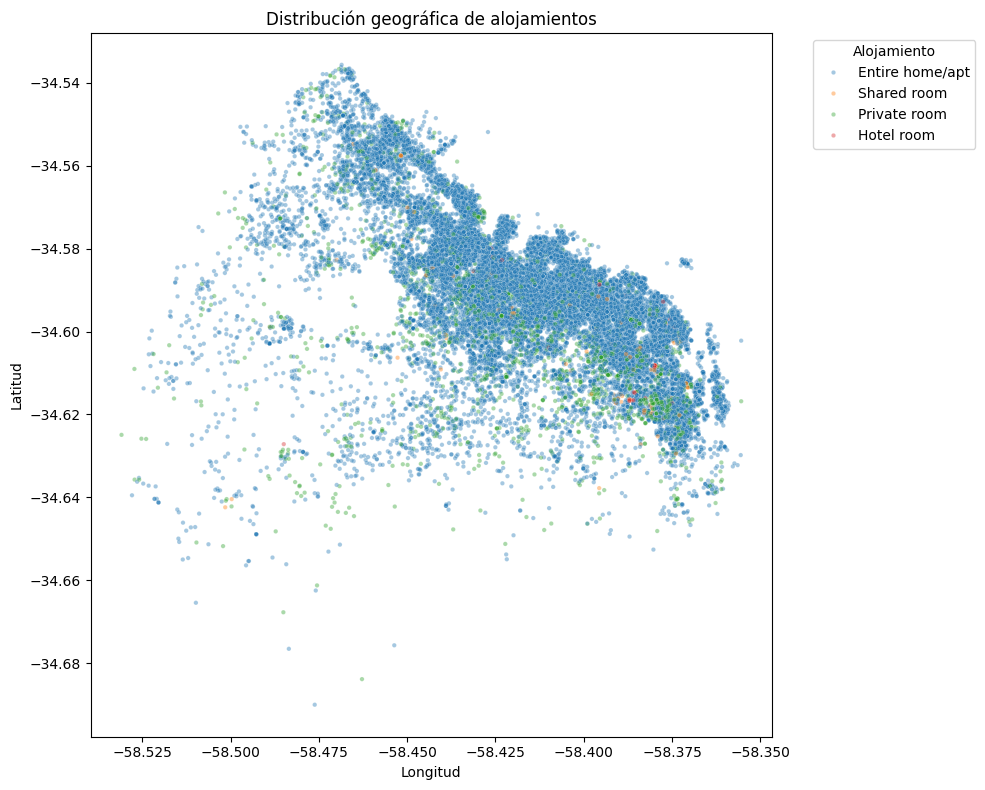

In [35]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='room_type', alpha=0.4, s=10)

plt.title('Distribución geográfica de alojamientos')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Alojamiento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Para probar la hipótesis de que este gráfico de dispersión tiene implícita la silueta de la Ciudad de Buenos Aires, se puede superponer el gráfico de dispersión con un mapa de la ciudad. De esta forma se puede verificar si los puntos del gráfico de dispersión coinciden con las zonas geográficas y barrios de la ciudad.

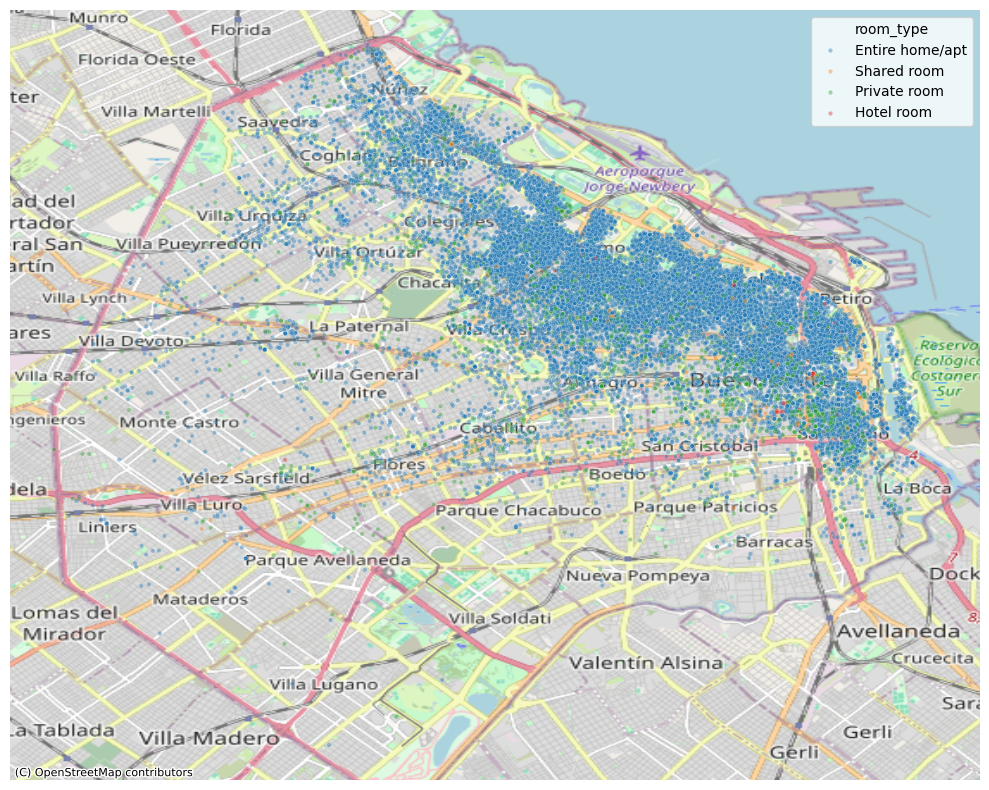

In [36]:
import contextily as ctx
from pyproj import Transformer

# Reproyectar a Web Mercator (que usa contextily)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x, y = transformer.transform(df['longitude'].values, df['latitude'].values)
df_merc = df.assign(x=x, y=y)

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=df_merc, x='x', y='y', hue='room_type', alpha=0.4, s=10, ax=ax)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
plt.tight_layout()
plt.show()


# 3. Plantear un posible problema de ML supervisado a partir de los datos elegidos

A partir de los datos explorados, el problema de ML supervisado que más sentido cobra es el de estimar la variable *precio*, ya que resultaría interesante poder predecir el precio de alquiler de inmuebles en función de sus características, como el tipo de alojamiento, la ubicación, el número de reseñas, etc.

Se trataría de un problema de regresión, ya que la variable a predecir es numérica. En particular, sería una regresión lineal múltiple, ya que se utilizarían varias variables independientes (a priori) para predecir el precio.

El problema principal en este caso es que todas las observaciones del conjunto tienen la variable *precio* con valores nulos, lo que dificulta el entrenamiento de un modelo de ML supervisado. Una posible solución podría ser tratar de calcular los precios a partir de cierta heurística con los datos disponibles, y con estas etiquetas fabricadas, entrenar el modelo.

# 4. Preprocesamiento y limpieza del dataset

# 5. Feature engineering

# 6. Reducción de dimensionalidad